## Prerequisites

Before beginning this chapter, you should be familiar with,

- basic set and logical operations
- basic idea of image and pixels
- basics idea of vectors and matrics
- morphological processing chapter

## Learning Objectives

After this section, you will be able to:

  - implement erosion, dilation, opening, and closing operations
  - apply various morphological operations in practical uses



## Erosion Implementation


In [1]:
!curl -o img.png "https://docs.opencv.org/3.4/Morphology_1_Tutorial_Theory_Original_Image.png"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100   422  100   422    0     0    820      0 --:--:-- --:--:-- --:--:--   822


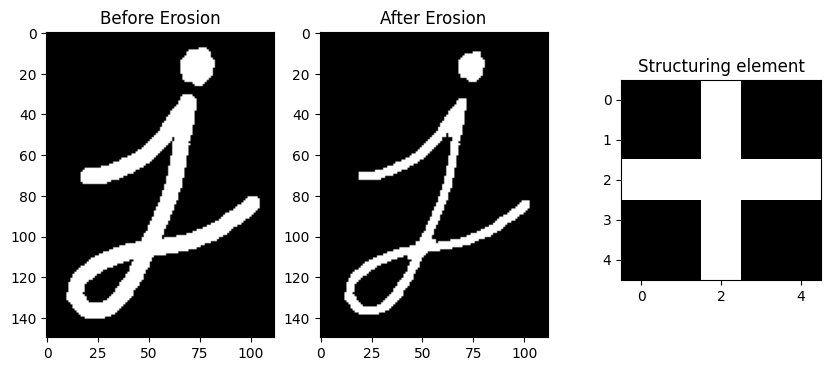

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create a structure element(SE).
erosion_type = cv2.MORPH_CROSS # choosing cross-shape SE
erosion_size = 2
# getStructuringElement takes three arguments (shape of SE, size of SE, anchor position of SE(orgin))
element = cv2.getStructuringElement(erosion_type, (2 * erosion_size + 1, 2 * erosion_size+1), (erosion_size , erosion_size))
img = cv2.imread("img.png")
# erode takes two arguments here,(image, SE)
eroded = cv2.erode(img, element)
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(img)
ax1.set_title("Before Erosion")
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(eroded)
ax2.set_title("After Erosion")
ax3 = fig.add_axes([.7, .4, .2, .2])
ax3.set_title("Structuring element")
ax3.imshow(element, cmap='gray')

Here, you see that after applying the erosion operation, the thickness of the character reduces. That is, the character has been more thinner than the original one. This is because the erosion operation has eroded the boundaries of regions of foreground pixels(white pixels). For detailed understanding of the functions like `getStructuringElement`, `erode`, you can follow the following links: [getStructuringElement](https://docs.opencv.org/4.4.0/d4/d86/group__imgproc__filter.html#gac342a1bb6eabf6f55c803b09268e36dc), [cv2.erode](https://docs.opencv.org/4.4.0/d4/d86/group__imgproc__filter.html#gaeb1e0c1033e3f6b891a25d0511362aeb).


## Dilation Implementation

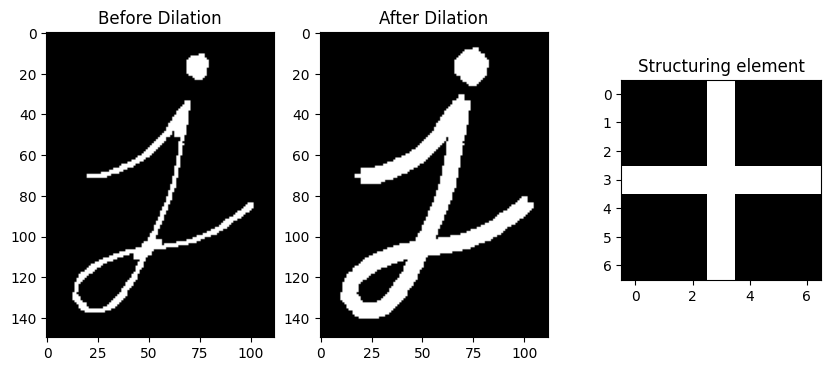

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create a structure element.
dilation_type = cv2.MORPH_CROSS ## choosing cross-shape SE
dilation_size = 3
element = cv2.getStructuringElement(dilation_type, (2 * dilation_size + 1, 2 * dilation_size+1), (dilation_size , dilation_size))
eroded = cv2.erode(img, element)
# Here, dilating the eroded image
# dilate takes two arguments here, (image, SE)
dilated = cv2.dilate(eroded, element)
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(eroded)
ax1.set_title("Before Dilation")
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(dilated)
ax2.set_title("After Dilation")
ax3 = fig.add_axes([.7, .4, .2, .2])
ax3.set_title("Structuring element")
ax3.imshow(element, cmap='gray')

In case you are still confused with that dilation is doing, notice the cross in the tip on j. This shape arises because of our structuring element. For detailed understanding of the function `dilate`, you can follow the following link: [cv2.dilate](https://docs.opencv.org/4.4.0/d4/d86/group__imgproc__filter.html#ga4ff0f3318642c4f469d0e11f242f3b6c).

## Opening and Closing Implementation

In [8]:
!curl -o img.jpg "https://upload.wikimedia.org/wikipedia/commons/thumb/9/9e/Plain_whorl_in_a_right_thumbprint.jpg/640px-Plain_whorl_in_a_right_thumbprint.jpg"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100  154k  100  154k    0     0   167k      0 --:--:-- --:--:-- --:--:--  167k


In [9]:
!curl -o img.png "https://docs.opencv.org/3.4/Morphology_1_Tutorial_Theory_Original_Image.png"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100   422  100   422    0     0   3148      0 --:--:-- --:--:-- --:--:--  3172


In [10]:
# Implementation
import cv2
import numpy as np
import matplotlib.pyplot as plt


Text(0.5, 1.0, 'After closing the opened')

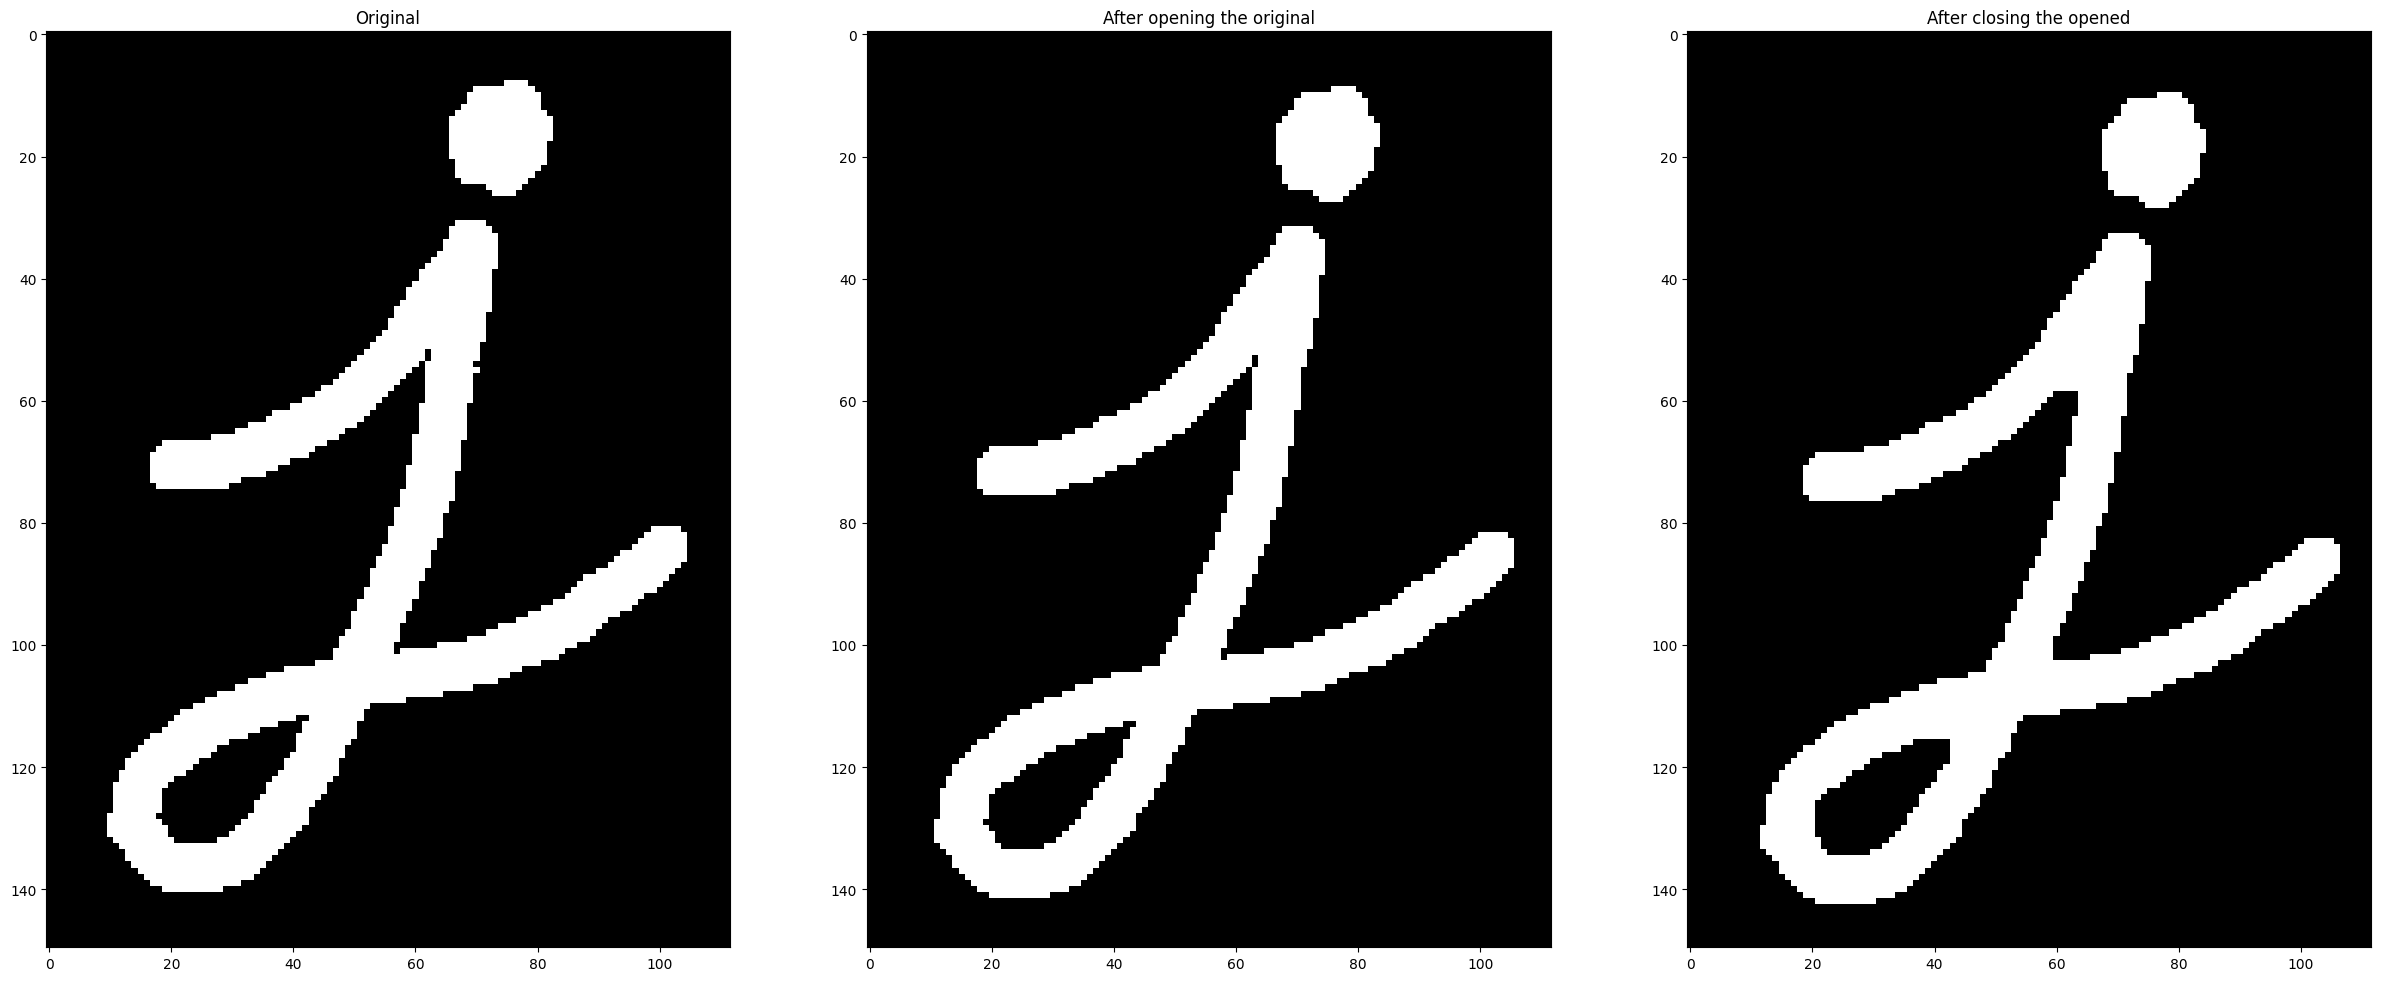

In [11]:
img = cv2.imread("img.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, img = cv2.threshold(img, 127, 255,cv2.THRESH_BINARY)
kernel = np.ones((4, 4), np.uint8)

# opening
opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
# closing after opening
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
fig = plt.figure(figsize=(30,20))

ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(img, cmap="gray")
ax1.set_title("Original")
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(opened, cmap="gray")
ax2.set_title("After opening the original")
ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(closed, cmap="gray")
ax3.set_title("After closing the opened")

In [ ]:
img = cv2.imread("testtext.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, img = cv2.threshold(img, 127, 255,cv2.THRESH_BINARY)
kernel = np.ones((4, 4), np.uint8)


# opening
opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
# closing after opening
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
fig = plt.figure(figsize=(30,20))

# dilation = cv2.dilate(img,kernel,iterations = 1)
# plt.imshow(img)

# img = cv.imread('j.png',0)
kernel1 = np.ones((3,3),np.uint8)
# erosion1 = cv2.morphologyEx(img,cv2.MORPH_HITMISS, kernel)
erosion1 = cv2.dilate(img, kernel1, iterations=1)
kernel2 = np.ones((3,3),np.uint8)
erosion2 = cv2.erode(erosion1,kernel2,iterations = 1)

ax1 = fig.add_subplot(1, 3, 1)
ax1.axis('off')
ax1.imshow(img, cmap='gray')
ax2 = fig.add_subplot(1, 3, 2)
ax2.axis('off')
ax2.imshow(erosion1, cmap='gray')
ax3 = fig.add_subplot(1, 3, 3)
ax3.axis('off')
ax3.imshow(erosion2, cmap='gray')
# ax1 = fig.add_subplot(1, 3, 1)
# ax1.imshow(img, cmap="gray")
# ax1.set_title("Original")
# ax2 = fig.add_subplot(1, 3, 2)
# ax2.imshow(opened, cmap="gray")
# ax2.set_title("After opening the original")
# ax3 = fig.add_subplot(1, 3, 3)
# ax3.imshow(closed, cmap="gray")
# ax3.set_title("After closing the opened")